In [125]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import yaml
import re
from scipy.stats import pearsonr

from analysis_scripts.us_analysis import *
from analysis_scripts.md_analysis import *
from analysis_scripts.gbsa_analysis import *
from analysis_scripts.docking_analysis import *

from analysis_scripts.plotstyle import set_rcparams
set_rcparams() # set plotting style

### Plotting a single timeseries

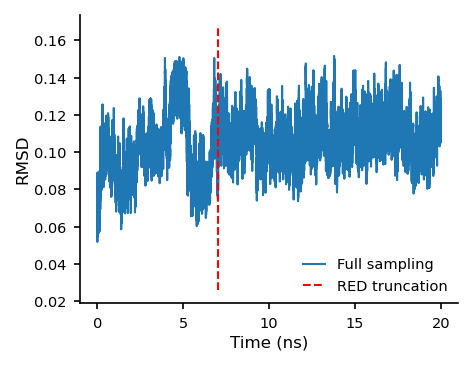

(array([0.000000e+00, 5.000125e-04, 1.000025e-03, ..., 1.999900e+01,
        1.999950e+01, 2.000000e+01], shape=(40000,)),
 array([0.05763369, 0.05591425, 0.06374597, ..., 0.1128919 , 0.10923853,
        0.11346262], shape=(40000,)))

In [126]:
system = 'BRD4_IBG1_DCAF16'
stage = 'RMSD'
dof = 'BD1_only_bulk'
n_run = 1
CV = 2.0

plot_timeseries(CV, system, stage, dof, equilibration='RED', run_number=n_run)

### Plotting histograms of equilibration times

In [127]:
ROOT = Path("/home/btan/Documents/MolecularGluesBFE")


def classify_rmsd_state(dof):
    """
    Classify RMSD calculations using the repository naming convention.

    Bound:
        *_only
        *with*

    Bulk:
        *_bulk
        bare component names
    """
    dof_lower = dof.lower()

    # Check bulk first because names such as
    # BD1_only_bulk and BD2withBD1_bulk contain "_only" or "with".
    if "_bulk" in dof_lower:
        return "Bulk-state RMSD"

    if dof_lower.endswith("_only") or "with" in dof_lower:
        return "Bound-state RMSD"

    return "Bulk-state RMSD"


def load_equilibration_times():
    records = []

    # Separation equilibration files
    for path in sorted(
        ROOT.glob("*/US/separation/results/run*/RED/equil_times.csv")
    ):
        relative_parts = path.relative_to(ROOT).parts

        system = relative_parts[0]
        repeat = int(relative_parts[4].replace("run", ""))

        data = pd.read_csv(path)

        for equilibration_time in data["equilibration_time_ns"]:
            records.append({
                "system": system,
                "stage": "Separation",
                "dof": "separation",
                "repeat": repeat,
                "equilibration_time_ns": equilibration_time,
                "file": str(path),
            })

    # RMSD equilibration files
    for path in sorted(
        ROOT.glob("*/US/RMSD/results/*/run*/RED/equil_times.csv")
    ):
        relative_parts = path.relative_to(ROOT).parts

        system = relative_parts[0]
        dof = relative_parts[4]
        repeat = int(relative_parts[5].replace("run", ""))

        stage = classify_rmsd_state(dof)
        data = pd.read_csv(path)

        for equilibration_time in data["equilibration_time_ns"]:
            records.append({
                "system": system,
                "stage": stage,
                "dof": dof,
                "repeat": repeat,
                "equilibration_time_ns": equilibration_time,
                "file": str(path),
            })

        # Remove the outlier
        records = [
            record for record in records
            if not (
                record["system"] == "BRD4_IBG1_DCAF16"
                and record["stage"] == "Bulk-state RMSD"
                and record["dof"] == "BD1_only_bulk"
                and record["repeat"] == 2
                and record["equilibration_time_ns"] > 10
            )
        ]

    if not records:
        raise RuntimeError(
            f"No equil_times.csv files found below {ROOT}"
        )

    return pd.DataFrame(records)


equilibration_df = load_equilibration_times()

# Display summary statistics
summary = (
    equilibration_df
    .groupby("stage")["equilibration_time_ns"]
    .agg(
        n="count",
        mean_ns="mean",
        std_ns="std",
        median_ns="median",
        minimum_ns="min",
        maximum_ns="max",
    )
)

display(summary)

,n,mean_ns,std_ns,median_ns,minimum_ns,maximum_ns
stage,,,,,,
Bound-state RMSD,1983,4.841278,2.801813,4.94600,0.0,9.0005
Bulk-state RMSD,1877,4.422367,2.909842,4.31250,0.0,9.0005
Separation,1530,1.569528,2.378695,0.30525,0.0,9.0005


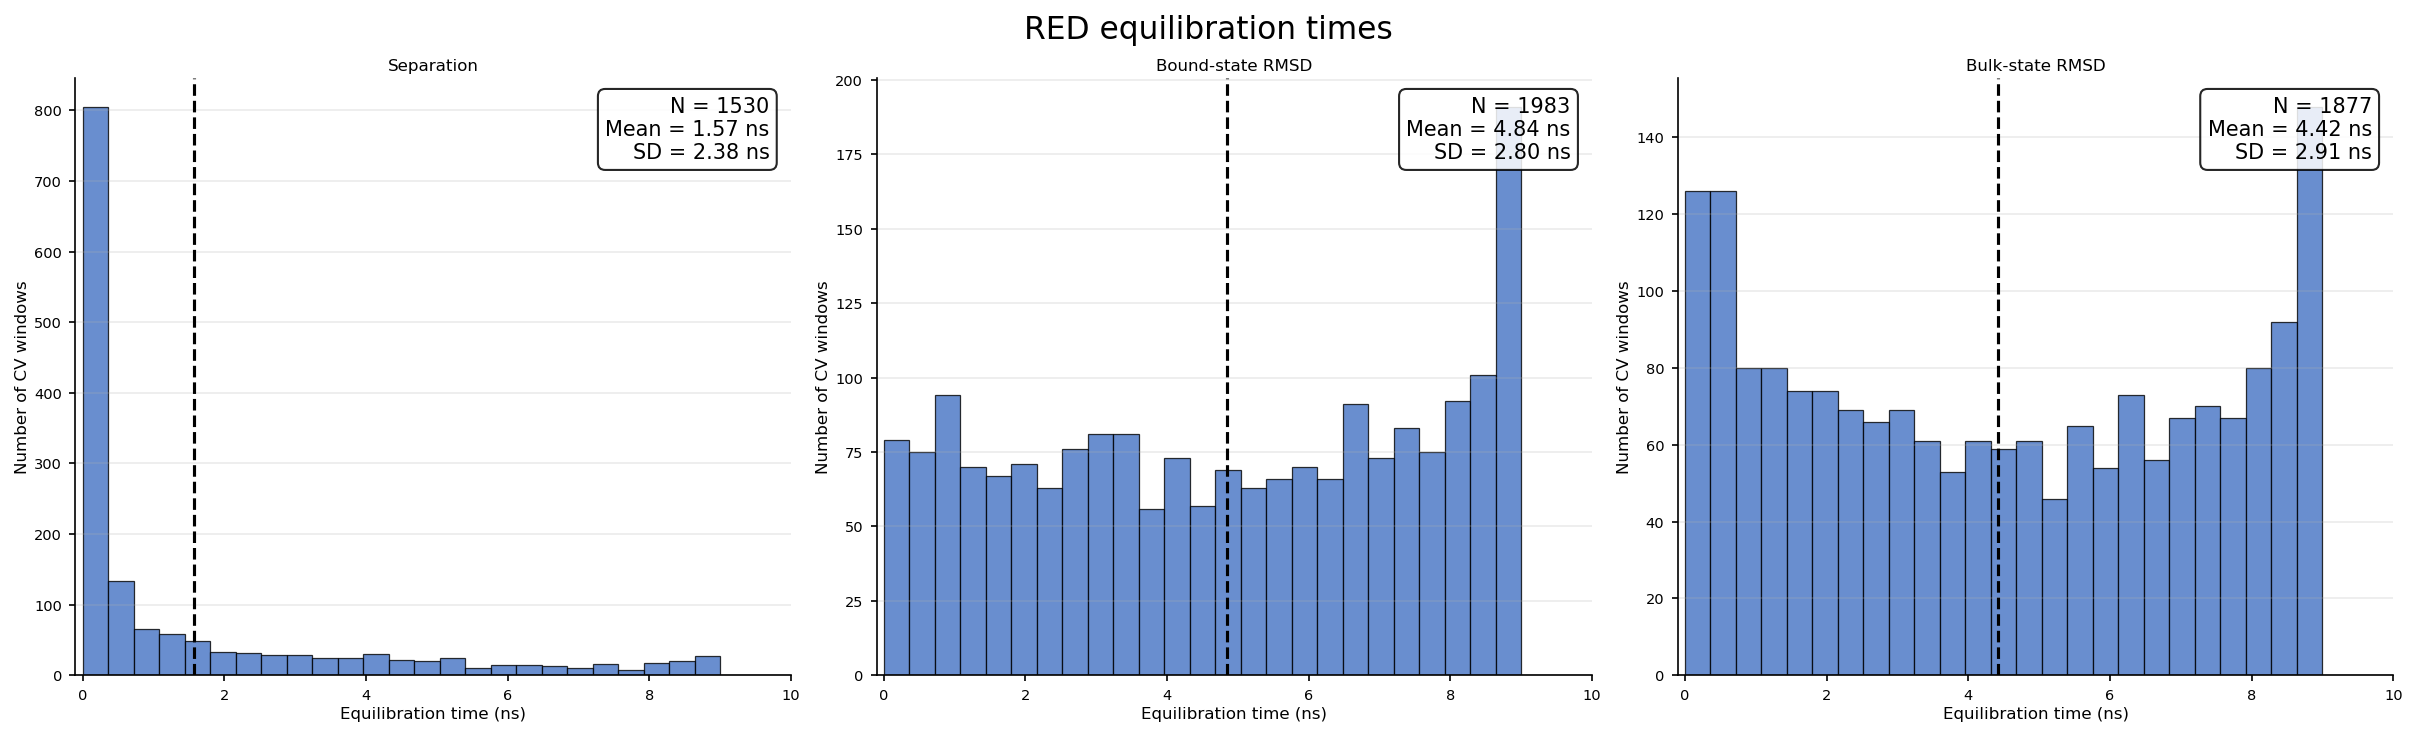

Saved figure to: /home/btan/Documents/MolecularGluesBFE/equilibration_time_histograms.png


In [128]:
stages = [
    "Separation",
    "Bound-state RMSD",
    "Bulk-state RMSD",
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 4.8),
    constrained_layout=True,
)

for ax, stage in zip(axes, stages):
    values = (
        equilibration_df.loc[
            equilibration_df["stage"] == stage,
            "equilibration_time_ns",
        ]
        .dropna()
        .to_numpy()
    )

    if len(values) == 0:
        ax.set_title(f"{stage}\nNo data")
        ax.set_axis_off()
        continue

    mean = np.mean(values)
    std = np.std(values, ddof=1)

    ax.hist(
        values,
        bins=25,
        color="#4472C4",
        alpha=0.8,
        edgecolor="black",
        linewidth=0.6,
    )

    ax.axvline(
        mean,
        color="black",
        linestyle="--",
        linewidth=1.5,
    )

    statistics_text = (
        f"N = {len(values)}\n"
        f"Mean = {mean:.2f} ns\n"
        f"SD = {std:.2f} ns"
    )

    ax.text(
        0.97,
        0.97,
        statistics_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox={
            "boxstyle": "round,pad=0.35",
            "facecolor": "white",
            "edgecolor": "black",
            "alpha": 0.85,
        },
    )

    ax.set_title(stage)
    ax.set_xlim(-0.1, 10.0)
    ax.set_xlabel("Equilibration time (ns)")
    ax.set_ylabel("Number of CV windows")
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("RED equilibration times", fontsize=15)

output_path = ROOT / "equilibration_time_histograms.png"
# fig.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved figure to: {output_path}")

### Plotting equilibration time for a single US repeat

<Axes: xlabel='CV (Angstrom)', ylabel='Equilibration time (ns)'>

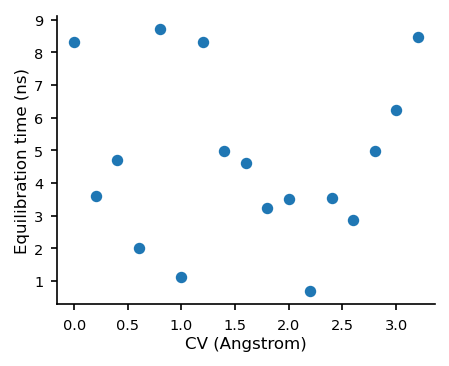

In [129]:
eq_df = write_equilibration_times('CRBN_len_CK1a', 'RMSD', dof='CRBN_len_only', run_number=3)
eq_df.plot(x='CV', y='equilibration_time_ns', ylabel='Equilibration time (ns)', xlabel='CV (Angstrom)', kind='scatter')

### Visualise the convergence trace

In [130]:
# Helper for single repeat Boresch contribution
def _get_overall_boresch_contribution(
    system,
    run_number=1,
    repo_root=Path.cwd(),
    k_restraint=100,
):
    """
    Calculate the overall Boresch contribution for one repeat.

    Parameters
    ----------
    system : str
        System directory name, e.g. "CRBN_len_CK1a".
    run_number : int
        Repeat number.
    repo_root : pathlib.Path
        Repository root directory.
    k_restraint : float
        Boresch restraint force constant in kcal/mol/rad^2.

    Returns
    -------
    total_contribution : float
        Overall Boresch contribution in kcal/mol.
    contributions : dict
        Individual Boresch DOF contributions.
    """

    repo_root = Path(repo_root)

    config_path = repo_root / system / "US" / "US_config.yaml"
    with open(config_path) as file:
        config = yaml.safe_load(file)

    equilibrium_values = {
        "thetaA": config["Boresch equilibrium values"]["theta_A_0"],
        "thetaB": config["Boresch equilibrium values"]["theta_B_0"],
        "phiA": config["Boresch equilibrium values"]["phi_A_0"],
        "phiB": config["Boresch equilibrium values"]["phi_B_0"],
        "phiC": config["Boresch equilibrium values"]["phi_C_0"],
    }

    contributions = {}

    for dof, theta_0 in equilibrium_values.items():
        pmf_path = (
            repo_root
            / system
            / "US"
            / "Boresch"
            / "results"
            / dof
            / f"run{run_number}"
            / "pmf.txt"
        )

        pmf_data = np.loadtxt(pmf_path)
        x = pmf_data[:, 0]
        pmf = pmf_data[:, 1]

        contributions[dof] = BoreschContribution(
            x=x,
            pmf=pmf,
            theta_0=theta_0,
            k_restraint=k_restraint,
        )

    total_contribution = sum(contributions.values())

    return total_contribution, contributions

In [131]:
def visualise_dg_conv(system, stage, plot=True):
    """
    Visualise how the DG estimate converges for a given stage
    stage is 'RMSD' or 'separation'

    Return:
        sampling time
        Overall average DG
        Repeat 1 DG
        Repeat 2 DG
        Repeat 3 DG
        SEM
    """
    filepath = f"{system}/US/{stage}"

    if stage == 'separation':
        filepath += '/results'

    df = pd.read_csv(f"{filepath}/dg_convergence.csv")

    sampling_time = df['sampling_time_ns'].to_numpy()
    dG = df['av_dg_kcal_mol'].to_numpy()
    err = df['sem_kcal_mol'].to_numpy()

    # Individual repeats
    r1 = df['dg_repeat1'].to_numpy()
    r2 = df['dg_repeat2'].to_numpy()
    r3 = df['dg_repeat3'].to_numpy()

    if plot == True:

        plt.title(system)
        plt.errorbar(sampling_time, dG, yerr=err, marker='s')
        plt.ylabel('DG Estimate (kcal/mol)')
        plt.xlabel('Sampling time (ns)')
        plt.show()

    return sampling_time, dG, r1, r2, r3, err

In [132]:
def visualise_sem_conv(systems, stage):
    """
    Visualise how the DG SEM converges for a given stage
    stage is 'RMSD' or 'separation'
    """
    for system in systems:

        filepath = f"{system}/US/{stage}"

        if stage == 'separation':
            filepath += '/results'

        df = pd.read_csv(f"{filepath}/dg_convergence.csv")

        sampling_time = df['sampling_time_ns'].to_numpy()
        dG = df['av_dg_kcal_mol'].to_numpy()
        err = df['sem_kcal_mol'].to_numpy()

        plt.plot(sampling_time, err, marker='s', label=system)
        # plt.plot(sampling_time, err[-1]*np.ones(len(sampling_time)), linestyle='dotted', c='k')

    plt.ylabel('Inter-repeat SEM (kcal/mol)')
    plt.xlabel('Sampling time (ns)')
    plt.legend()
    plt.show()

In [133]:
def obtain_overall_DG(system, sep_time, rmsd_time):
    """
    Obtain the overall DG estimate at the specified separation and RMSD
    sampling times.
    """

    sep_dg_data = visualise_dg_conv(system, "separation", plot=False)
    sep_idx = np.where(
        np.isclose(sep_dg_data[0], sep_time)
    )[0][0]
    sep_dgs = np.array([
        sep_dg_data[n][sep_idx] for n in range(2, 5)
    ])

    rmsd_dg_data = visualise_dg_conv(system, "RMSD", plot=False)
    rmsd_idx = np.where(
        np.isclose(rmsd_dg_data[0], rmsd_time)
    )[0][0]
    rmsd_dgs = np.array([
        rmsd_dg_data[n][rmsd_idx] for n in range(2, 5)
    ])

    # Standard-state correction is independent of repeat
    full_data = pd.read_csv(f"{system}/US/deltaG_stages.csv")
    ssc = full_data.loc[
        full_data["Stage"] == "Standard state corr",
        "dG (kcal/mol)",
    ].iloc[0]

    # Boresch contribution for each repeat
    boresch_dgs = np.array([
        _get_overall_boresch_contribution(
            system=system,
            run_number=run_number,
        )[0]
        for run_number in range(1, 4)
    ])

    dgs = sep_dgs + rmsd_dgs + boresch_dgs + ssc

    # Remove incomplete or excluded repeats
    valid = np.isfinite(dgs)
    dgs = dgs[valid]

    if len(dgs) < 2:
        raise ValueError("Fewer than two valid repeats are available.")

    overall_dg = np.mean(dgs)
    overall_sem = np.std(dgs, ddof=1) / np.sqrt(len(dgs))

    return float(overall_dg), float(overall_sem)

In [134]:
obtain_overall_DG('BRD4_IBG3_DCAF16', 20, 16)

(-13.69642410729304, 0.4915338870460728)

### CRBN-len-CK1a

In [135]:
def read_exp_deltaG(system):
    """Read experimental deltaG

    Also return the label for plotting
    """

    if 'CRBN' in system:
        filename = 'CRBN_exp.csv'
    else:
        filename = 'DCAF16_exp.csv'

    df = pd.read_csv(f'exp_data/{filename}')
    row = df.loc[df['system'] == system].iloc[0]

    return row['G (kcal/mol)'], row['σ G (kcal/mol)'], row['label']

In [173]:
sep_sampling_time = 30
rmsd_sampling_time = 20

#### Correlation plot

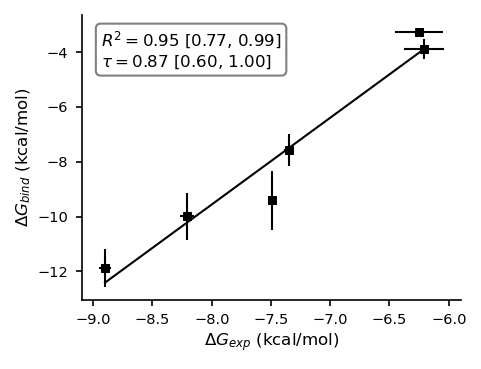

In [174]:
from analysis_scripts.bootstrap_stats import compute_report_stats

systems = ['CRBN_CK1a', 'CRBN_len_CK1aG40N', 'CRBN_len_CK1aN39G',
           'CRBN_len_CK1aI37E', 'CRBN_len_CK1aI35G', 'CRBN_len_CK1a']

x     = [read_exp_deltaG(sys)[0] for sys in systems]
x_err = [read_exp_deltaG(sys)[1] for sys in systems]

y     = [obtain_overall_DG(sys, sep_sampling_time, rmsd_sampling_time)[0] for sys in systems]
y_err = [obtain_overall_DG(sys, sep_sampling_time, rmsd_sampling_time)[1] for sys in systems]

# --- Bootstrap statistics (R², Kendall tau, MUE, RMSE) ---
boot_stats    = compute_report_stats(x, x_err, y, y_err)
r2_result     = boot_stats["R2"]
kendall_result = boot_stats["Kendall"]

# --- Linear fit ---
coeffs = np.polyfit(x, y, 1)
fit_fn = np.poly1d(coeffs)
y_fit  = fit_fn(x)

# --- Plot ---
plt.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='s', label='Data', c='k')
plt.plot(x, y_fit, linestyle='-', c='k')

# --- Annotate with point estimates and 95% bootstrap CIs ---
textstr = (
    f"$R^2 = {r2_result.point:.2f}$"
    f" [{r2_result.ci_low:.2f}, {r2_result.ci_high:.2f}]\n"
    f"$\\tau = {kendall_result.point:.2f}$"
    f" [{kendall_result.ci_low:.2f}, {kendall_result.ci_high:.2f}]"
)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))

plt.xlabel('$\Delta G_{exp}$ (kcal/mol)')
plt.ylabel('$\\Delta G_{bind}$ (kcal/mol)')
plt.tight_layout()
plt.show()


#### Bar plot

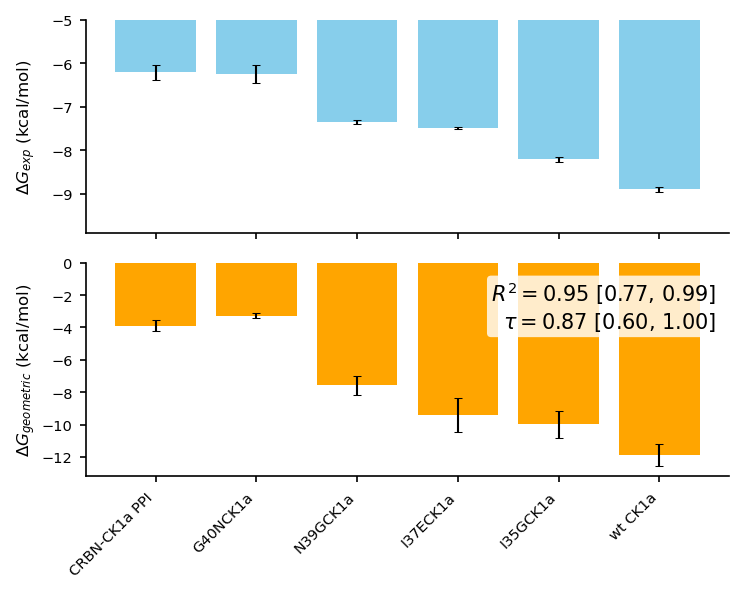

0.621282985471537


In [175]:
# Plotting
fig, axs = plt.subplots(2, 1, figsize=(5, 4), sharex=True)
x = np.arange(len(systems))

systems = ['CRBN_CK1a', 'CRBN_len_CK1aG40N', 'CRBN_len_CK1aN39G',
           'CRBN_len_CK1aI37E', 'CRBN_len_CK1aI35G', 'CRBN_len_CK1a']

labels = [read_exp_deltaG(sys)[2] for sys in systems]

exp_vals     = [read_exp_deltaG(sys)[0] for sys in systems]
exp_err_vals = [read_exp_deltaG(sys)[1] for sys in systems]

calc_vals     = [obtain_overall_DG(sys, sep_sampling_time, rmsd_sampling_time)[0] for sys in systems]
calc_err_vals = [obtain_overall_DG(sys, sep_sampling_time, rmsd_sampling_time)[1] for sys in systems]

axs[0].bar(x, exp_vals, yerr=exp_err_vals, capsize=2, color='skyblue')
axs[0].set_ylabel('$\Delta G_{{exp}}$ (kcal/mol)')
axs[0].set_ylim(-9.9, -5.0)

axs[1].bar(x, calc_vals, yerr=calc_err_vals, capsize=2, color='orange')
axs[1].set_ylabel('$\Delta G_{{geometric}}$ (kcal/mol)')

# --- Annotation with 95% bootstrap CIs ---
annotation = (
    f"$R^2 = {r2_result.point:.2f}$ [{r2_result.ci_low:.2f}, {r2_result.ci_high:.2f}]\n"
    f"$\\tau = {kendall_result.point:.2f}$ [{kendall_result.ci_low:.2f}, {kendall_result.ci_high:.2f}]"
)
axs[1].text(
    0.98, 0.92, annotation,
    transform=axs[1].transAxes, ha="right", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8)
)

# Set labels
axs[-1].set_xticks(x)
axs[-1].set_xticklabels(labels, rotation=45, ha='right')

plt.tight_layout()
fig.align_ylabels(axs)
plt.show()

print(np.average(calc_err_vals))

#### Standard error

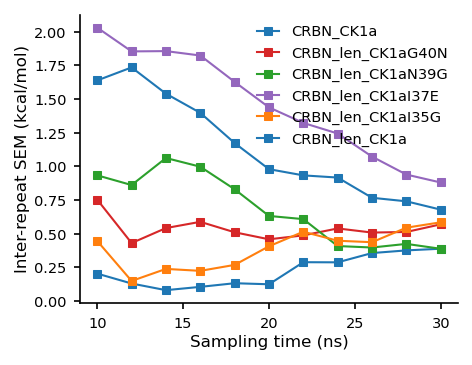

In [81]:
visualise_sem_conv(systems, 'separation')

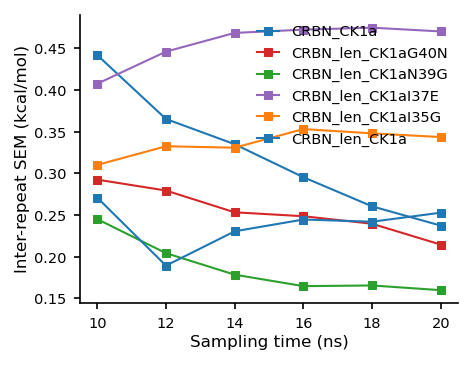

In [82]:
visualise_sem_conv(systems, 'RMSD')

### DCAF16 systems

In [171]:
sep_sampling_time = 30
rmsd_sampling_time = 20

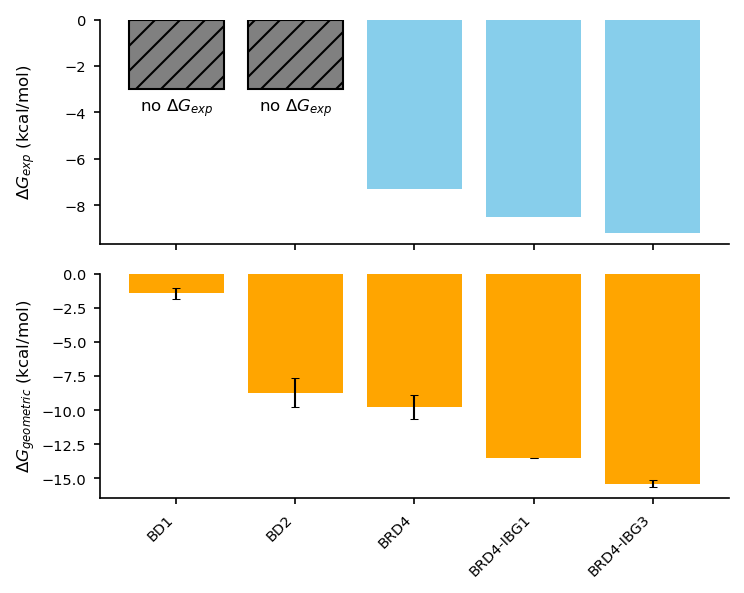

0.5263503258085788


In [172]:
systems = ['BD1_DCAF16', 'BD2_DCAF16', 'BRD4_DCAF16',
           'BRD4_IBG1_DCAF16', 'BRD4_IBG3_DCAF16']

labels = [read_exp_deltaG(sys)[2] for sys in systems]

exp_vals = [read_exp_deltaG(sys)[0] for sys in systems]
exp_err_vals = [read_exp_deltaG(sys)[1] for sys in systems]

calc_vals = [obtain_overall_DG(sys, sep_sampling_time, rmsd_sampling_time)[0] for sys in systems]
calc_err_vals = [obtain_overall_DG(sys, sep_sampling_time, rmsd_sampling_time)[1] for sys in systems]

fig, axs = plt.subplots(2, 1,  figsize=(5,4), sharex=True)
x = np.arange(len(systems))

axs[0].set_ylabel('$\Delta G_{{exp}}$ (kcal/mol)')
axs[0].bar(x[2:], exp_vals[2:],  color='skyblue')
bars = axs[0].bar(x[:2], exp_vals[:2], color='grey')
for b in bars:
    b.set_hatch('//')
    b.set_edgecolor('black')
# axs[0].set_ylim()
    
for i, b in enumerate(bars):
    x_pos = b.get_x() + b.get_width() / 2
    y_pos = b.get_height()
    axs[0].text(
        x_pos, y_pos - 0.3,   # adjust vertical offset as needed
        'no $\Delta G_{{exp}}$',
        ha='center', va='top',
        fontsize=8
    )

axs[1].bar(x, calc_vals, yerr=calc_err_vals, capsize=2, color='orange')
axs[1].set_ylabel('$\Delta G_{{geometric}}$ (kcal/mol)')


# Set labels
axs[-1].set_xticks(x)
axs[-1].set_xticklabels(labels, rotation=45, ha='right')

plt.tight_layout()
fig.align_ylabels(axs)
plt.show()

print(np.average(calc_err_vals))

Text(0.5, 0, 'Time (ns)')

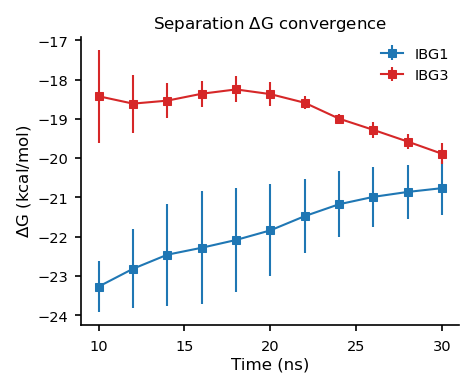

In [102]:
# IBG1 vs IBG3 comparison

conv_ibg1 = visualise_dg_conv('BRD4_IBG1_DCAF16', 'separation', plot=False)
conv_ibg3 = visualise_dg_conv('BRD4_IBG3_DCAF16', 'separation', plot=False)

plt.title('Separation $\Delta$G convergence')
plt.errorbar(conv_ibg1[0], conv_ibg1[1], yerr=conv_ibg1[-1], label='IBG1', marker='s')
plt.errorbar(conv_ibg3[0], conv_ibg3[1], yerr=conv_ibg3[-1], label='IBG3', marker='s')
plt.legend()
plt.ylabel('$\Delta$G (kcal/mol)')
plt.xlabel('Time (ns)')

Text(0.5, 0, 'Separation US sampling time (ns)')

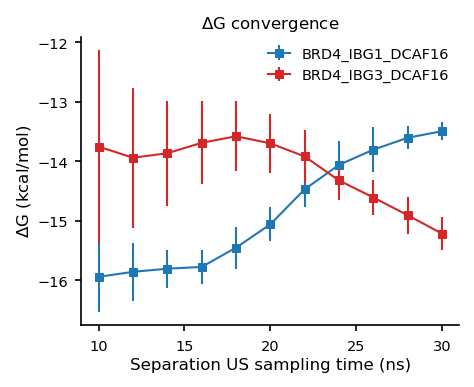

In [109]:
# IBG1 vs IBG3 comparison

for system in ['BRD4_IBG1_DCAF16', 'BRD4_IBG3_DCAF16']:

    sep_sampling = [10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
    DGs = []
    SEMs = []

    for t in sep_sampling:

        DG, SEM = obtain_overall_DG(system, t, 16)
        DGs.append(DG)
        SEMs.append(SEM)

    plt.errorbar(sep_sampling, DGs, yerr=SEMs, label=system, marker='s')

plt.title('$\Delta$G convergence')
plt.legend()
plt.ylabel('$\Delta$G (kcal/mol)')
plt.xlabel('Separation US sampling time (ns)')

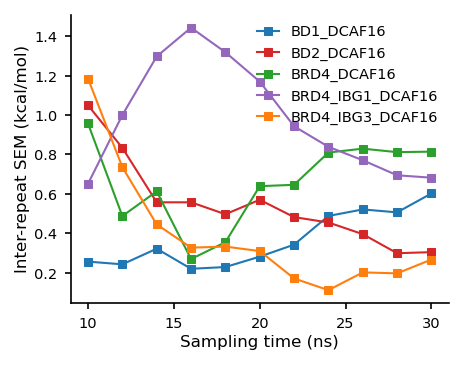

In [92]:
visualise_sem_conv(systems, 'separation')

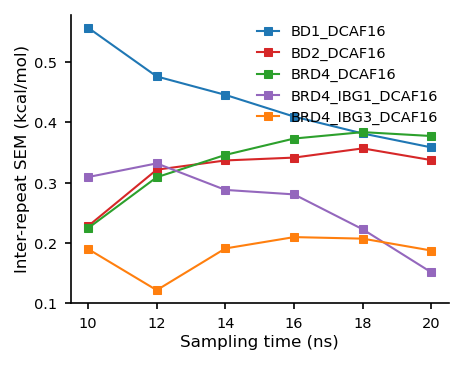

In [68]:
visualise_sem_conv(systems, 'RMSD')

### BRD4 vs BRD3 selectivity

In [184]:
def read_exp_abundance(system):
    """Read experimental deltaG

    Also return the label for plotting
    """

    filename = 'DCAF16_abundances.csv'

    df = pd.read_csv(f'exp_data/{filename}')
    row = df.loc[df['system'] == system].iloc[0]

    return row['abundance'], row['σ'], row['label']

In [191]:
sep_sampling_time = 30
rmsd_sampling_time = 20

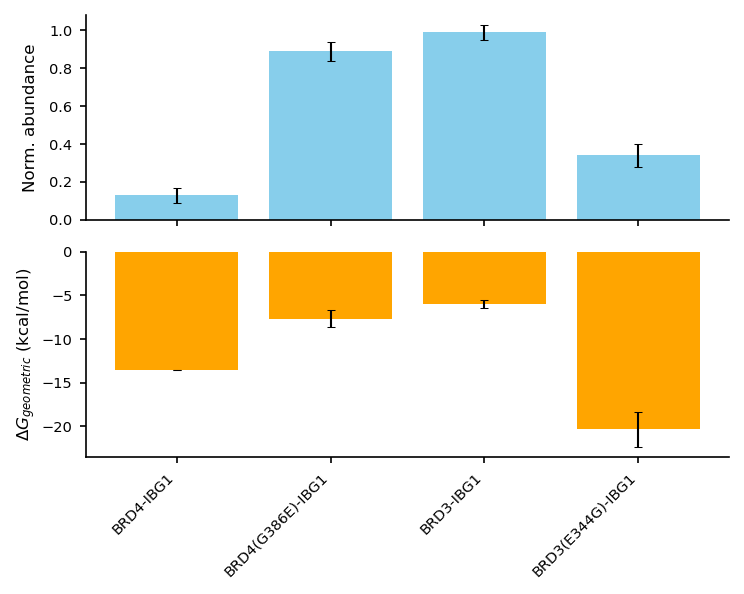

0.8718012968408256


In [192]:
systems = ['BRD4_IBG1_DCAF16', 'BRD4G386E_IBG1_DCAF16', 'BRD3_IBG1_DCAF16', 'BRD3E344G_IBG1_DCAF16']

labels = [read_exp_abundance(sys)[2] for sys in systems]

exp_vals = [read_exp_abundance(sys)[0] for sys in systems]
exp_err_vals = [read_exp_abundance(sys)[1] for sys in systems]

calc_vals = [obtain_overall_DG(sys, sep_sampling_time, rmsd_sampling_time)[0] for sys in systems]
calc_err_vals = [obtain_overall_DG(sys, sep_sampling_time, rmsd_sampling_time)[1] for sys in systems]

fig, axs = plt.subplots(2, 1, figsize=(5,4), sharex=True)
x = np.arange(len(systems))

axs[0].bar(x, exp_vals, yerr=exp_err_vals, capsize=2, color='skyblue')
axs[0].set_ylabel('Norm. abundance')
   
axs[1].bar(x, calc_vals, yerr=calc_err_vals, capsize=2, color='orange')
axs[1].set_ylabel('$\Delta G_{{geometric}}$ (kcal/mol)')

# Set labels
axs[-1].set_xticks(x)
axs[-1].set_xticklabels(labels, rotation=45, ha='right')

plt.tight_layout()
fig.align_ylabels(axs)
plt.show()

print(np.average(calc_err_vals))


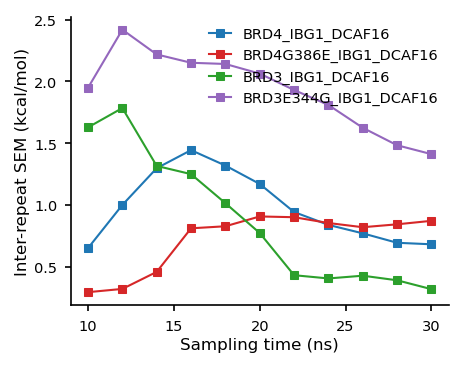

In [117]:
visualise_sem_conv(systems, 'separation')

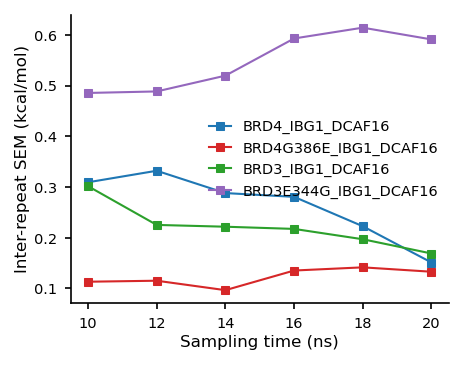

In [118]:
visualise_sem_conv(systems, 'RMSD')

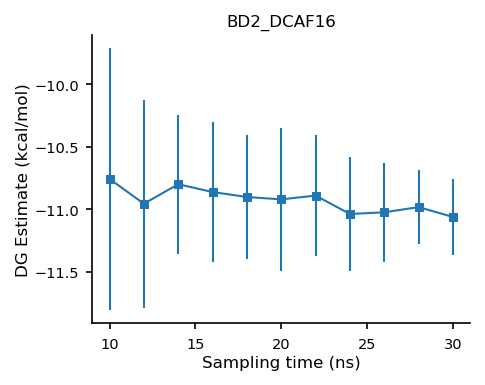

(array([10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]),
 array([-10.75733571, -10.95577299, -10.79977228, -10.86222387,
        -10.90213587, -10.92106854, -10.89066638, -11.03781384,
        -11.02423148, -10.98293717, -11.06154533]),
 array([ -9.92221691,  -9.91938899,  -9.81223784,  -9.7493831 ,
         -9.91150243,  -9.82526845,  -9.98777373, -10.19627378,
        -10.30019626, -10.42222324, -10.51220991]),
 array([ -9.50660909, -10.34302036, -10.84770105, -11.46058706,
        -11.4514598 , -11.73992089, -11.63283886, -11.75596094,
        -11.66058084, -11.43940462, -11.56120217]),
 array([-12.84318114, -12.60490963, -11.73937795, -11.37670144,
        -11.3434454 , -11.19801627, -11.05138656, -11.1612068 ,
        -11.11191735, -11.08718366, -11.11122392]),
 array([1.04980091, 0.83358755, 0.55683335, 0.55694707, 0.4962972 ,
        0.56979485, 0.48164062, 0.45445035, 0.39514898, 0.2982253 ,
        0.30383502]))

In [183]:
visualise_dg_conv('BD2_DCAF16', 'separation', plot=True)